# ADEPT Architectural Analysis: Anti-Corruption Layer Pattern
This notebook provides a comprehensive walkthrough of the ADEPT framework's analysis pipeline. We analyze the **Anti-Corruption Layer** pattern, exploring how it isolates a downstream system from the semantics of an upstream system by translating requests. We evaluate how the overhead of this layer impacts response time and resource utilization across different workload distributions.


In [1]:
# Set project root in path so we can import 'adept' package
import sys
sys.path.append("../../")

# %matplotlib inline
import itertools
import pandas as pd
import matplotlib.pyplot as plt
import json

from adept import PatternAnalysis

## 1. Preprocessing Logic
Raw simulation data often contains tool-specific column names and numeric identifiers. In this step, we:
- **Rename outputs**: Map simulation variables `R0` to `response_time` and `Uacl` to `utilization`.
- **Filter and Sort**: Isolate relevant architectural parameters and sort by client count (`N_A`).
- **Standardize Schema**: Initialize policy identifiers and model names to prepare the data for the consolidated ADEPT session.

In [2]:
# Specific parameters for Anti-Corruption Layer
INPUT_PARAMETERS = ['N_A', 'N_B', 'r_Z_A', 'r_Z_B', 'C_SS1', 'r_A_SS1', 'r_B_SS1', 'p_SS1toACL_A', 'p_SS1toRef_A',
                    'p_SS1toACL_B', 'p_SS1toRef_B', 'r_A_ACL', 'r_B_ACL', 'r_A_SS2', 'r_B_SS2']
OUTPUTS = ['response_time', 'utilization'] # Utilization if for the ACL, although it could also be for SS1 and SS2

# N = 24
# C = 1

def preprocess_acl(df: pd.DataFrame) -> pd.DataFrame:

    filter_cols = INPUT_PARAMETERS + ['R0', 'Uacl']
    df = df[filter_cols].copy()
    
    df.rename(columns={'R0': 'response_time', 'Uacl': 'utilization'}, inplace=True)

    # df = df[df['N_A']+df['N_B']==self.N]
    df.sort_values(by='N_A', inplace=True)
    df.reset_index(inplace=True, drop=True)

    experiments_df = df[INPUT_PARAMETERS].copy()
    experiments_df.index.name = 'scenario'
    experiments_df.reset_index(inplace=True)
    experiments_df['model'] = 'anticorruption_layer'
    experiments_df['policy'] = 'standard' #0 # np.nan #float('nan')
    # The only policy (i.e. design decision) is the selection of 3 services being aggregated by the gateway
    experiments_df['policy'] = experiments_df['policy'].astype('category')

    experiments_df[OUTPUTS] = df[OUTPUTS]

    return experiments_df



In [3]:
# test_df = pd.read_csv("./multi_N25_p.csv")
# preprocess_acl(test_df)

## 2. Initialize and Load Data
We initialize a `PatternAnalysis` session using a declarative system definition (JSON). The preprocessor defined in Step 1 is injected here to automate the data ingestion pipeline.

In [4]:
json_path = "Anti_Corruption_Layer.json"
session = PatternAnalysis(json_path)

# Load using the programmatic preprocessor hook
session.load(validate_integrity=True, preprocessor=preprocess_acl)

print(f"Loaded {len(session.raw_df)} experiments.")
session.raw_df.head()

Loading configuration file (standard): multi_N25_p.csv
  -> Loaded 234 rows.
  -> Applying preprocessor to standard...
Merged 1 files into dataframe with shape: (234, 20)
Data integrity validation passed successfully.
Loaded 234 experiments.


,scenario,N_A,N_B,r_Z_A,r_Z_B,C_SS1,r_A_SS1,r_B_SS1,p_SS1toACL_A,p_SS1toRef_A,p_SS1toACL_B,p_SS1toRef_B,r_A_ACL,r_B_ACL,r_A_SS2,r_B_SS2,model,policy,response_time,utilization
0,0,0,25,0.05,0.01,1,0.083333,1.666667,0.8,0.2,0.2,0.8,0.05,0.2,0.03125,0.235294,anticorruption_layer,standard,104.205254,0.299704
1,1,0,25,0.05,0.01,1,0.083333,1.666667,0.1,0.9,0.9,0.1,0.05,0.2,0.03125,0.235294,anticorruption_layer,standard,1128.544383,0.999385
2,2,0,25,0.05,0.01,1,0.083333,1.666667,0.5,0.5,0.5,0.5,0.05,0.2,0.03125,0.235294,anticorruption_layer,standard,142.257765,0.904008
3,3,0,25,0.05,0.01,1,0.083333,1.666667,0.3,0.7,0.7,0.3,0.05,0.2,0.03125,0.235294,anticorruption_layer,standard,294.202801,0.988126
4,4,0,25,0.05,0.01,1,0.083333,1.666667,0.7,0.3,0.3,0.7,0.05,0.2,0.03125,0.235294,anticorruption_layer,standard,107.532000,0.496755


## 3. Define Tradeoffs (The Qualitative Shift)
We translate raw metrics into architectural concepts (e.g., 'Fast' vs 'Slow'). ADEPT utilizes an automated configuration engine that processes the data immediately upon tradeoff creation. You can choose between:
- **Discretization**: Simple combinatorial grid of bins (Low/Avg/High).
- **Thresholds**: Strict binary classification based on SLAs.
- **Pareto**: Identifying optimal regions where gains in one objective require sacrifices in another.

In [5]:
# ---- 1. Discretization into 3 bins
target_labels = {
    'response_time': ['XS', 'S', 'M', 'L'],
    'utilization': ['XS', 'S', 'M', 'L']
}
tradeoffs, schemes = session.create_tradeoffs(method='discretization', labels=target_labels)


# ---- 2. Static thresholds
# thresholds = {
#     'response_time': (3000, '<'),      # Strict limit
#     'utilization': (0.7, '<=') # Minimum requirement
# }
# tradeoffs, schemes = session.create_tradeoffs(method='threshold', thresholds=thresholds)


# ---- 3. Pareto (Nadir point)
# tradeoffs, schemes = session.create_tradeoffs(method='pareto') #, objectives=['response_time', 'utilization'])


# ---- 4. Pareto-epsilon
# tradeoffs, schemes = session.create_tradeoffs(method='pareto_epsilon', epsilon=0.05)

# ---- 5. Clustering
# tradeoffs, schemes = session.create_tradeoffs(method='clustering')


Creating discretization tradeoffs with 4 bins.


In [6]:
print(len(tradeoffs), "possible tradeoffs (regions)")
for scheme in schemes:
    print(f"Objective: {scheme.objective_name}")
    for b in scheme.bins:
        print(f"  {b.label}: [{b.min_value:.2f}, {b.max_value:.2f}]")

16 possible tradeoffs (regions)
Objective: response_time
  XS: [101.41, 1893.12]
  S: [1893.12, 3684.82]
  M: [3684.82, 5476.53]
  L: [5476.53, 7268.23]
Objective: utilization
  XS: [0.04, 0.30]
  S: [0.30, 0.57]
  M: [0.57, 0.83]
  L: [0.83, 1.10]


## 4. Data Splitting
To ensure findings generalize beyond the current samples, we split the data into Training and Test sets. This split is stratified by tradeoff membership to preserve the representation of rare performance modes.

In [7]:
session.split_data(test_size=0.4, remove_outliers=True, verbose=True)

Outlier removal: Dropped 4 rows based on outcome Z-scores > 3.0.
Data split: 138 train, 92 test.

--- Train Set Tradeoff Counts ---
  XS,XS: 1 (0.72%)
  XS,S: 11 (7.97%)
  XS,M: 77 (55.80%)
  XS,L: 49 (35.51%)
  S,M: 0 (0.00%)
  L,M: 0 (0.00%)

--- Test Set Tradeoff Counts ---
  XS,XS: 1 (1.09%)
  XS,S: 1 (1.09%)
  XS,M: 65 (70.65%)
  XS,L: 24 (26.09%)
  S,M: 1 (1.09%)
  L,M: 0 (0.00%)


## 5. Outcome Distributions
We visually confirm the spread of our metrics. This step helps verify that our discretization boundaries align with the natural performance characteristics of the Gateway Offloading system.

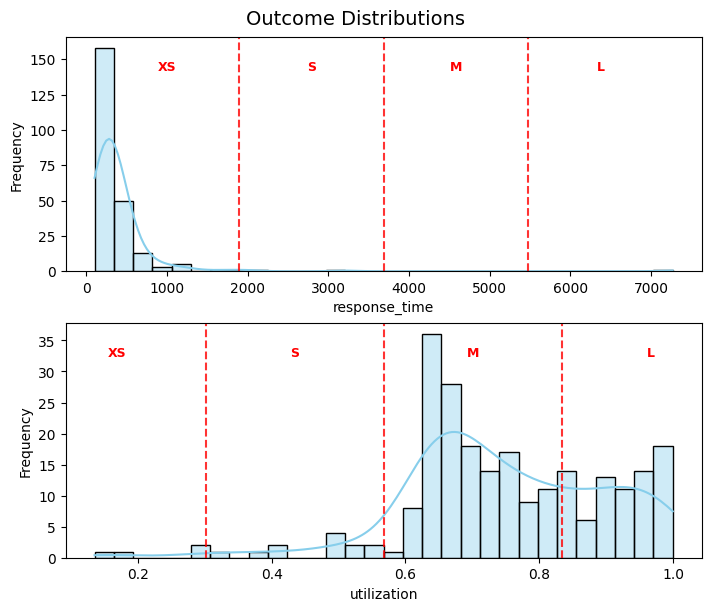

In [8]:
session.show_distributions(figsize=(7,3))
plt.show()

In [9]:
# Looking at each tradeoff region
# for tradeoff in session.get_tradeoffs():
#     indices = session.get_indices_for_tradeoff(tradeoff)
#     print(f"Plotting distribution for target tradeoff: {tradeoff.name}")
   
#     session.show_distributions(
#         tradeoff=tradeoff,
#         highlight_indices=indices
#     )
#     plt.show()

## 6. Quality Objective Space (2D Scatter)
We map the tradeoffs onto a 2D space to see their shape and density. Readability enhancements include bottom-aligned legends and bottom-to-top orientation for Y-axis bin labels.

In [10]:
tradeoff_labels = [t.name for t in tradeoffs]
tradeoff_labels


['XS-XS',
 'XS-S',
 'XS-M',
 'XS-L',
 'S-XS',
 'S-S',
 'S-M',
 'S-L',
 'M-XS',
 'M-S',
 'M-M',
 'M-L',
 'L-XS',
 'L-S',
 'L-M',
 'L-L']

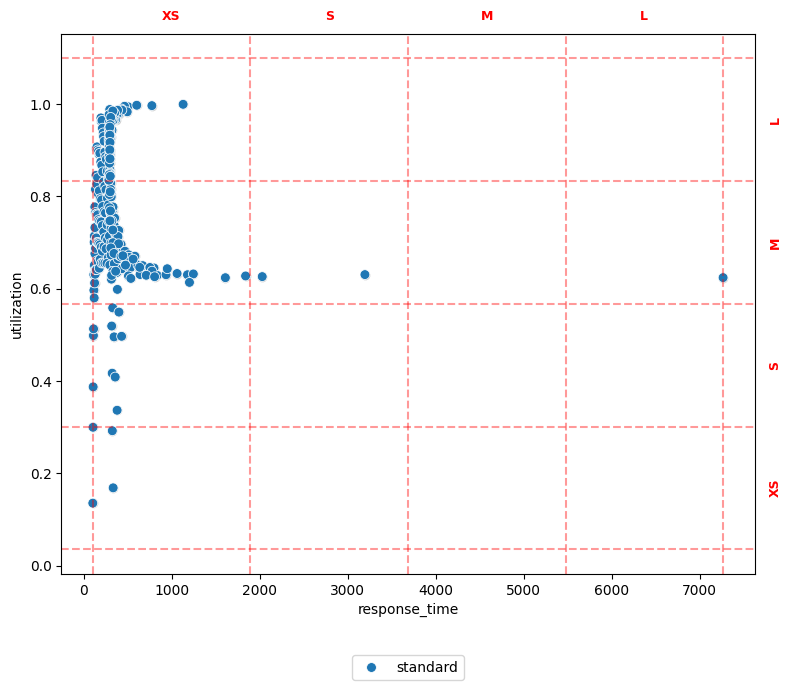

In [11]:
outcome_cols = list(session.outcomes_df.columns)
# Plot the policies for all combinations (pairs) of quality objectives
for x_col, y_col in itertools.combinations(outcome_cols, 2):
    fig = session.show_quality_objective_space(
        x_col, y_col,
        highlight_policies=session.get_policies(), 
        # highlight_tradeoffs=[session.get_tradeoff(tradeoffs[4].name)],
        # show_overall=True,
        subset='all',
        cmap='tab10', 
        alpha=1.0,
        figsize=(8, 7),
        s=50,
        title=""
    )
    fig.savefig(f'acl-quality_objective_space_{x_col}_{y_col}.png', dpi=500)
    plt.show()

## 7. Contingency Analysis (Impact of Decisions)
This stage quantifies the relationship between choices and outcomes. We compute:
- **Heatmaps**: Visualizing the probability of landing in a specific tradeoff given a policy.
- **Deterministic Policies**: Identifying configurations that lead to a single outcome with >99% certainty.
- **Exclusive Tradeoffs**: Determining if certain high-performance results are only reachable via a specific design path.

Analyzing Decision: invocation_strategy


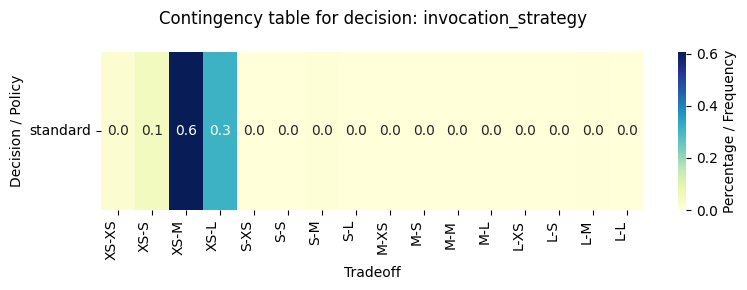

In [12]:
decisions = list(session.get_decisions().keys())
for decision_key in decisions:
    print(f"Analyzing Decision: {decision_key}")
    session.show_policy_contingency(
        decision_key, 
        type='heatmap', 
        subset='all',
        title=f"Contingency table for decision: {decision_key}",
        figsize=(8,3)
    )
    plt.show()

In [13]:
print("Deterministic policies (policies that consistently result in a single specific tradeoff)")
for decision_key in decisions:
    print("---"*10)
    print("Decision:", decision_key)
    for policy, tradeoff in session.get_deterministic_policies(decision_key):
        print("* Policy:", policy, "--> Tradeoff:", tradeoff)


Deterministic policies (policies that consistently result in a single specific tradeoff)
------------------------------
Decision: invocation_strategy


In [14]:
session.get_policies()

{'standard': SystemConfiguration(name='standard', description='', pattern_policy_references=[PatternPolicyReference(component='acl_pattern', decision='invocation_strategy', policy='standard')], source_file='multi_N25_p.csv', component_policies={})}

In [15]:
print("Exclusive tradeoffs (tradeoffs being addressed by a single decision (which might have several policies)")
for decision_key in decisions:
    print("---"*10)
    print("Decision:", decision_key)
    for policy, tradeoff in session.get_exclusive_tradeoffs(decision_key):
        print("* Tradeoff:", tradeoff, "--> Decision:", decision_key, "[Policy:", policy, "]")

 

Exclusive tradeoffs (tradeoffs being addressed by a single decision (which might have several policies)
------------------------------
Decision: invocation_strategy
* Tradeoff: XS-XS --> Decision: invocation_strategy [Policy: standard ]
* Tradeoff: XS-S --> Decision: invocation_strategy [Policy: standard ]
* Tradeoff: XS-M --> Decision: invocation_strategy [Policy: standard ]
* Tradeoff: XS-L --> Decision: invocation_strategy [Policy: standard ]
* Tradeoff: S-M --> Decision: invocation_strategy [Policy: standard ]
* Tradeoff: L-M --> Decision: invocation_strategy [Policy: standard ]


## 8. Robustness Analysis (Quantifying Stability)
While contingency tells us *how often* we succeed, robustness tells us *how stable* that success is when parameters vary. We use two complementary metrics:
- **STARR (Success Rate)**: The percentage of points within a policy that meet the target requirements. Higher is better.
- **REGRET (Risk)**: The standardized distance from the closest successful point. It measures 'how bad' a failure is. Lower is better.

In [16]:
metric = 'starr' #'starr 'regret'

In [17]:
base_robustness_matrix = session.get_robustness_report(metric=metric, subset='test') 
base_robustness_matrix # Test


,XS-XS,XS-S,XS-M,XS-L,S-XS,S-S,S-M,S-L,M-XS,M-S,M-M,M-L,L-XS,L-S,L-M,L-L
policy,,,,,,,,,,,,,,,,
standard,0.01087,0.01087,0.706522,0.26087,0.0,0.0,0.01087,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [18]:
# session.get_policy_contingency_matrix(decision_key, subset='test')

Robustness Ranking for Tradeoff: XS-XS
  1. standard: 0.02% success
  Top Policy -> standard - Starr: 0.0171 - Regret: 3.0644
Robustness Ranking for Tradeoff: XS-S
  1. standard: 0.05% success
  Top Policy -> standard - Starr: 0.0513 - Regret: 1.3880
Robustness Ranking for Tradeoff: XS-M
  1. standard: 0.61% success
  Top Policy -> standard - Starr: 0.6068 - Regret: 0.3701
Robustness Ranking for Tradeoff: XS-L
  1. standard: 0.31% success
  Top Policy -> standard - Starr: 0.3120 - Regret: 0.8453
Robustness Ranking for Tradeoff: S-XS
  1. standard: 0.00% success
  Top Policy -> standard - Starr: 0.0000 - Regret: 6.6519
Robustness Ranking for Tradeoff: S-S
  1. standard: 0.00% success
  Top Policy -> standard - Starr: 0.0000 - Regret: 6.0558
Robustness Ranking for Tradeoff: S-M
  1. standard: 0.01% success
  Top Policy -> standard - Starr: 0.0085 - Regret: 5.8818
Robustness Ranking for Tradeoff: S-L
  1. standard: 0.00% success
  Top Policy -> standard - Starr: 0.0000 - Regret: 5.9754
Ro

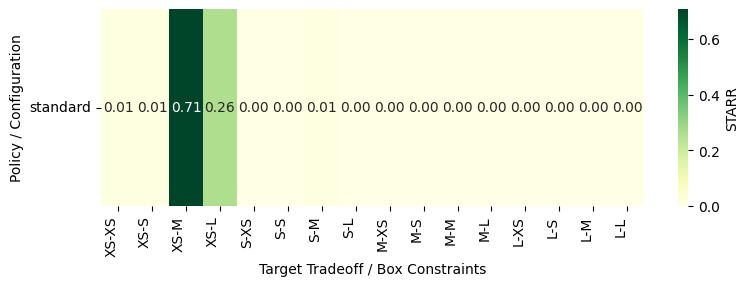

In [19]:
for tradeoff in session.get_tradeoffs():
    print(f"Robustness Ranking for Tradeoff: {tradeoff.name}")
    ranking = session.get_policy_robustness_ranking(tradeoff.name, metric='starr')
    for i, (pol, val) in enumerate(ranking[:3]):
        print(f"  {i+1}. {pol}: {val:.2f}% success")
    
    if ranking:
        top_pol = ranking[0][0]
        starr = session.compute_robustness(top_pol, tradeoff.name, metric='starr')
        regret = session.compute_robustness(top_pol, tradeoff.name, metric='regret')
        print(f"  Top Policy -> {top_pol} - Starr: {starr.get('value', 0.0):.4f} - Regret: {regret.get('value', 0.0):.4f}")

if metric == 'starr':
    print("Overall Robustness Heatmap (STARR):")
    session.show_robustness_heatmap(matrix=base_robustness_matrix, metric='starr', figsize=(8,3))
    plt.show()

if metric == 'regret':
    print("Overall Robustness Heatmap (REGRET):")
    session.show_robustness_heatmap(matrix=base_robustness_matrix, metric='regret', figsize=(8,3))
    plt.show()


## 9. Feature Importance (Sensitivity Analysis)
Not all parameters are equal. Using Random Forests, we rank features by their influence on outcomes. This identified which system parameters (e.g., service rates, user counts) truly 'drive' the architectural tradeoffs we defined in Step 3.

Scoring features for outcome: response_time (on subset: train)
Original features: ['N_A', 'N_B', 'p_SS1toACL_A', 'p_SS1toRef_A', 'p_SS1toRef_B', 'r_A_SS2', 'r_B_SS1', 'r_B_ACL', 'p_SS1toACL_B', 'r_B_SS2', 'r_A_ACL', 'r_Z_A', 'r_A_SS1', 'r_Z_B']
Features selected: ['N_A', 'p_SS1toRef_B', 'r_A_SS2', 'r_B_SS1', 'r_B_ACL', 'r_B_SS2', 'r_A_ACL', 'r_Z_A', 'r_A_SS1', 'r_Z_B']
Scoring features for outcome: utilization (on subset: train)
Original features: ['N_A', 'N_B', 'p_SS1toACL_A', 'p_SS1toRef_A', 'p_SS1toRef_B', 'r_A_SS2', 'r_B_SS1', 'r_B_ACL', 'p_SS1toACL_B', 'r_B_SS2', 'r_A_ACL', 'r_Z_A', 'r_A_SS1', 'r_Z_B']
Features selected: ['N_A', 'p_SS1toRef_A', 'r_A_SS2', 'r_B_SS1', 'r_B_ACL', 'r_B_SS2', 'r_A_ACL', 'r_Z_A', 'r_A_SS1', 'r_Z_B']


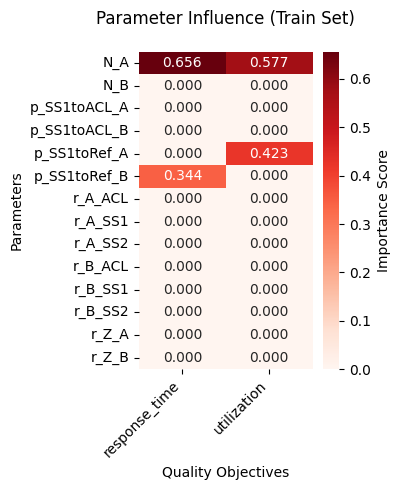

In [20]:
# Note: using smart correlation is more aggresive in the pruning of features, before scoring them
scores_df = session.compute_feature_scores(use_smart_correlation=True, subset='train')

session.show_feature_heatmap(scores_df, title="Parameter Influence (Train Set)", figsize=(4,5))
plt.show()

## 10. Scenario Discovery (PRIM)
We use the Patient Rule Induction Method (PRIM) to 'peel' the parameter space and find the 'Operating Envelopes' (Boxes) that reliably guarantee success. These rules define the boundaries of our robust architectural region for each target tradeoff.

In [21]:
# Key parameters used in the ECSA paper
# kp = ['N_A', 'N_B'] + ['p_SS1toACL_A', 'p_SS1toRef_A', 'p_SS1toACL_B', 'p_SS1toRef_B']


In [22]:
weighted_features = session.get_weighted_feature_ranking(scores_df)
print(weighted_features)
key_parameters = session.select_top_k_parameters(scores_df, index_order=weighted_features, threshold=0.2, k=None)
print("Key parameters (for scenario discovery):", key_parameters)

# key_parameters = kp # To make it similar to the ECSA paper

['N_A', 'p_SS1toRef_A', 'p_SS1toRef_B']
Key parameters (for scenario discovery): ['N_A', 'p_SS1toRef_A', 'p_SS1toRef_B']


In [23]:
prim_boxes = []
for tradeoff in session.get_tradeoffs():
    print("---"*10)
    print(f"Discovering scenarios for: {tradeoff.name}")
    boxes = session.discover_scenarios(
        tradeoff.name, method='prim', 
        threshold=0.8, 
        standardize=True,
        parameters=key_parameters
    )
    if boxes:
        best_box = boxes[0]
        print(f"* Key Rules: {best_box.limits}")
        print(f"* Metrics: {best_box.metrics}")
        prim_boxes.append(best_box)
    else:
        print("--> No scenarios discovered.")

------------------------------
Discovering scenarios for: XS-XS
Running PRIM discovery for: XS-XS ...
Instances satisfying property: False    137
True       1
Name: count, dtype: int64
Total instances: (138, 3)
Running PRIM ... rhodium
2 possible boxes
{'N_A': {'min': 0, 'max': 25}, 'p_SS1toRef_A': {'min': 0.0999999999999999, 'max': 0.9}, 'p_SS1toRef_B': {'min': 0.0999999999999999, 'max': 0.9}}
* Key Rules: {'N_A': {'min': 0.0, 'max': 15.5}, 'p_SS1toRef_A': {'min': 0.1499999999999999, 'max': 0.25}}
* Metrics: {'density': 0.0, 'coverage': 0.0, 'population_prevalence': 0.007246376811594203, 'lift': -0.007246376811594203, 'samples_in_box': 9.0, 'targets_in_box': 0.0}
------------------------------
Discovering scenarios for: XS-S
Running PRIM discovery for: XS-S ...
Instances satisfying property: False    127
True      11
Name: count, dtype: int64
Total instances: (138, 3)
Running PRIM ... rhodium
1 possible boxes
{'N_A': {'min': 0, 'max': 25}, 'p_SS1toRef_A': {'min': 0.0999999999999999, '

/Users/adiazpace/opt/anaconda3/envs/perfmodels/lib/python3.11/site-packages/prim/prim_box.py:415: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.peeling_trajectory = pd.concat([self.peeling_trajectory, pd.DataFrame([stats])],
/Users/adiazpace/opt/anaconda3/envs/perfmodels/lib/python3.11/site-packages/prim/prim_box.py:415: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.peeling_trajectory = pd.concat([self.peeling_trajectory, pd.DataFrame([stats])],
/Users/adiazpace/opt/anaconda3/envs/perf

In [24]:
boxes_to_keep = []
print("Summary of PRIM boxes:")
for idx, box in enumerate(prim_boxes):
    if not box.is_empty():
        lift = box.metrics.get('lift', None)
        print(f" {idx+1}. For tradeoff {box.target_tradeoff} ({box.target_tradeoff_labels}): lift={lift:.2f} \n\t{box.limits}")
        # print(box.actual_limits)
        boxes_to_keep.append(box)
    else:
        solutions = box.metrics.get('targets_in_box', 0)
        print(f" Skipping empty box. For tradeoff {box.target_tradeoff} ({box.target_tradeoff_labels}) {solutions}")
prim_boxes = boxes_to_keep


Summary of PRIM boxes:
 Skipping empty box. For tradeoff XS-XS (XS,XS) 0.0
 Skipping empty box. For tradeoff XS-S (XS,S) 1.0
 3. For tradeoff XS-M (XS,M): lift=0.41 
	{'N_A': {'min': 5.5, 'max': 25.0}, 'p_SS1toRef_A': {'min': 0.09999999999999987, 'max': 0.45}}
 4. For tradeoff XS-L (XS,L): lift=0.44 
	{'N_A': {'min': 0.0, 'max': 16.5}, 'p_SS1toRef_A': {'min': 0.55, 'max': 0.9}}


In [25]:
# Print prim_boxes to a JSON file
with open('prim_boxes-acl.json', 'w') as f:
    json_boxes = [box.model_dump() for box in prim_boxes]
    json.dump(json_boxes, f, indent=4)


## 11. Global Discovery (CART)
Using decision trees, we partition the entire design space into regions, providing a global map of the most likely outcomes for any input combination.

In [26]:
boxes_to_keep = []
cart_boxes = session.discover_scenarios(
                method='cart', 
                standardize=True, 
                parameters=key_parameters
            )
for idx, box in enumerate(cart_boxes):
    if not box.is_empty():
        lift = box.metrics.get('lift', None)
        print(f" {idx+1}. For tradeoff {box.target_tradeoff} ({box.target_tradeoff_labels}): lift={lift:.2f} \n\t{box.limits}")
        # print(box.actual_limits)
        boxes_to_keep.append(box)
    else:
        solutions = box.metrics.get('targets_in_box', 0)
        print(f" Skipping empty box. For tradeoff {box.target_tradeoff} ({box.target_tradeoff_labels}) {solutions}")
cart_boxes = boxes_to_keep

Running CART global discovery for all tradeoff combinations ...
 1. For tradeoff XS-M (XS,M): lift=0.35 
	{'N_A': {'min': 12.58695652173913, 'max': inf}}
 2. For tradeoff XS-L (XS,L): lift=-0.11 
	{'N_A': {'min': 12.58695652173913, 'max': 14.4986691475883}, 'p_SS1toRef_A': {'min': 0.5500756627429659, 'max': inf}}
 Skipping empty box. For tradeoff XS-S (XS,S) 0.0


In [27]:
# Print cart_boxes to a JSON file
with open('cart_boxes-acl.json', 'w') as f:
    json_boxes = [box.model_dump() for box in cart_boxes]
    json.dump(json_boxes, f, indent=4)


## 12. Potential Robustness Improvements (What-If Analysis)
Finally, we simulate the impact of applying discovered scenario constraints. We compare **Baseline Robustness** vs. **Improved Robustness** to quantify the value of the discovered 'Operating Envelopes' for each policy.

In [28]:
combined_df = session.get_robustness_results(prim_boxes, cart_boxes, baseline=base_robustness_matrix)
combined_df.to_csv('results-acl.csv', index=False, decimal=',')
combined_df

,method,policy,target,L-L,L-M,L-S,L-XS,M-L,M-M,M-S,M-XS,S-L,S-M,S-S,S-XS,XS-L,XS-M,XS-S,XS-XS
0,test set,standard,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.010870,0.0,0.0,0.260870,0.706522,0.01087,0.010870
1,prim,standard,XS-L,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.793103,0.206897,0.00000,0.000000
2,prim,standard,XS-M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.028571,0.0,0.0,0.000000,0.971429,0.00000,0.000000
3,cart,standard,XS-L,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.250000,0.750000,0.00000,0.000000
4,cart,standard,XS-M,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.022222,0.0,0.0,0.044444,0.911111,0.00000,0.022222


In [29]:
prim_box_list = session.align_boxes_to_tradeoffs(prim_boxes) # PRIM

prim_robustness_improvement_matrix = session.get_policy_robustness_improvement_matrix(prim_box_list, metric=metric, subset='test')
prim_robustness_improvement_matrix

,XS-XS,XS-S,XS-M,XS-L,S-XS,S-S,S-M,S-L,M-XS,M-S,M-M,M-L,L-XS,L-S,L-M,L-L
standard,None,None,0.971429,0.793103,None,None,None,None,None,None,None,None,None,None,None,None


In [30]:
session.get_tradeoff_coverage_matrix(prim_boxes, subset='test')

,XS-XS,XS-S,XS-M,XS-L,S-XS,S-S,S-M,S-L,M-XS,M-S,M-M,M-L,L-XS,L-S,L-M,L-L
XS-M,0.0,0.0,0.523077,0.000000,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
XS-L,0.0,0.0,0.092308,0.958333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [31]:
# fig = session.show_policy_robustness_improvement_heatmap(
#     boxes=prim_box_list, 
#     matrix=prim_robustness_improvement_matrix,
#     metric=metric,
#     figsize=(8, 4),
#     title="What-If Analysis: Policy Success under Box Constraints (PRIM)"
# )


In [32]:
cart_box_list = session.align_boxes_to_tradeoffs(cart_boxes) # CART

cart_robustness_improvement_matrix = session.get_policy_robustness_improvement_matrix(cart_box_list, metric=metric, subset='test')
cart_robustness_improvement_matrix

,XS-XS,XS-S,XS-M,XS-L,S-XS,S-S,S-M,S-L,M-XS,M-S,M-M,M-L,L-XS,L-S,L-M,L-L
standard,None,None,0.911111,0.25,None,None,None,None,None,None,None,None,None,None,None,None


In [33]:
session.get_tradeoff_coverage_matrix(cart_boxes, subset='test')

,XS-XS,XS-S,XS-M,XS-L,S-XS,S-S,S-M,S-L,M-XS,M-S,M-M,M-L,L-XS,L-S,L-M,L-L
XS-M,1.0,0.0,0.630769,0.083333,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
XS-L,0.0,0.0,0.046154,0.041667,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [34]:
# fig = session.show_policy_robustness_improvement_heatmap(
#     boxes=cart_box_list, 
#     matrix=cart_robustness_improvement_matrix,
#     metric=metric,
#     figsize=(8, 4),
#     title="What-If Analysis: Policy Success under Box Constraints (CART)"
# )

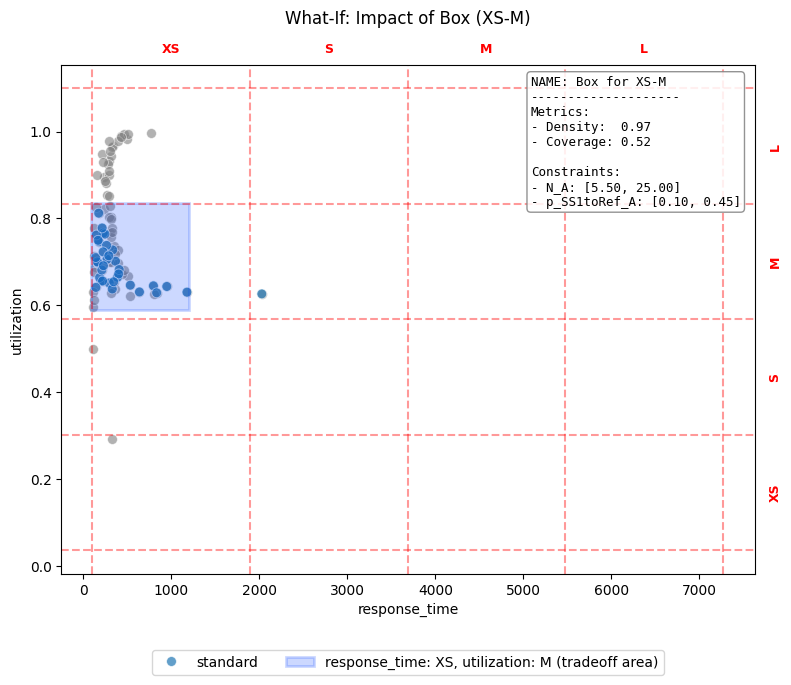

In [35]:
# Visualization of any example box
idx = 2
for x_col, y_col in itertools.combinations(outcome_cols, 2):
    session.show_box_impact_objective_space(
        box=prim_box_list[idx],
        x_metric=x_col, 
        y_metric=y_col,
        tradeoff=session.get_tradeoff(tradeoffs[idx].name),
        show_box_summary=True,
        subset='test',
        cmap='tab10', 
        alpha=0.7,
        figsize=(8, 7),
        s=50
    )
    plt.show()

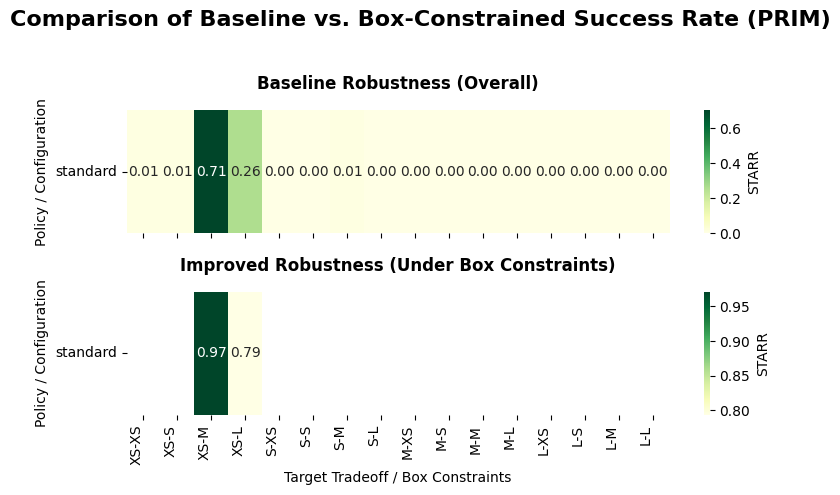

In [36]:
fig = session.show_policy_robustness_comparison_heatmap(
    baseline_matrix=base_robustness_matrix,
    improved_matrix=prim_robustness_improvement_matrix,
    boxes=prim_box_list, 
    metric=metric, 
    figsize=(8,5),
    title="Comparison of Baseline vs. Box-Constrained Success Rate (PRIM)"
)

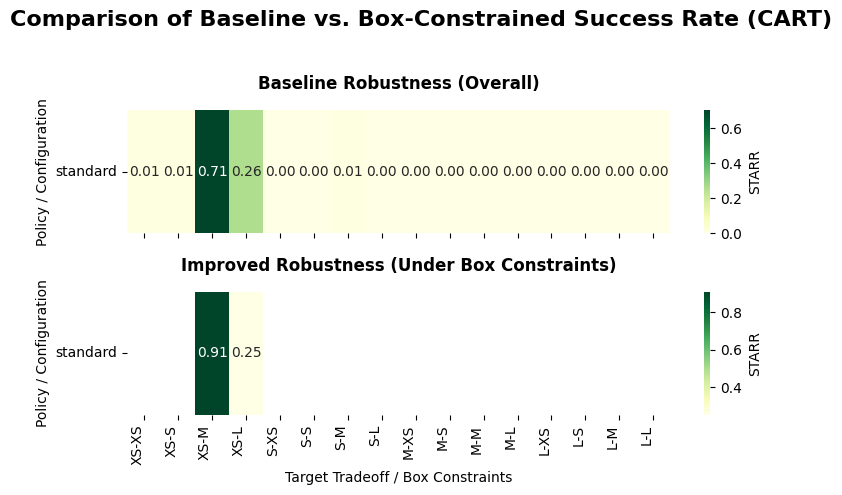

In [37]:
fig = session.show_policy_robustness_comparison_heatmap(
    baseline_matrix=base_robustness_matrix,
    improved_matrix=cart_robustness_improvement_matrix,
    boxes=cart_box_list, 
    metric=metric, 
    figsize=(8,5),
    title="Comparison of Baseline vs. Box-Constrained Success Rate (CART)"
)

## 13. Performance Metrics

In [38]:
# PRIM
scores = session.get_algorithm_performance_scores(prim_boxes, return_std=True)
metrics_df = pd.DataFrame(scores.items(), columns=['metric', 'value'])
df = metrics_df.T
prim_df = pd.DataFrame(df.values[1:], columns=df.iloc[0])
metrics_df

,metric,value
0,precision,0.116222
1,recall,0.086117
2,f1,0.097434
3,lift,0.143260
4,complexity,2.000000
5,success_rate,0.333333
6,precision_std,0.307713
7,recall_std,0.233671
8,f1_std,0.259564
9,lift_std,0.241075


In [39]:
# CART
scores = session.get_algorithm_performance_scores(cart_boxes, return_std=True)
metrics_df = pd.DataFrame(scores.items(), columns=['metric', 'value'])
df = metrics_df.T
cart_df = pd.DataFrame(df.values[1:], columns=df.iloc[0])
metrics_df

,metric,value
0,precision,0.089276
1,recall,0.045654
2,f1,0.053083
3,lift,0.071403
4,complexity,1.500000
5,success_rate,0.333333
6,precision_std,0.238299
7,recall_std,0.159990
8,f1_std,0.176253
9,lift_std,0.134819


In [40]:
all_metrics = pd.concat([prim_df, cart_df], axis=0)
all_metrics.index = ['prim', 'cart']
all_metrics.to_csv('metrics-acl.csv')
all_metrics


metric,precision,recall,f1,lift,complexity,success_rate,precision_std,recall_std,f1_std,lift_std,complexity_std
prim,0.116222,0.086117,0.097434,0.14326,2.0,0.333333,0.307713,0.233671,0.259564,0.241075,0.0
cart,0.089276,0.045654,0.053083,0.071403,1.5,0.333333,0.238299,0.15999,0.176253,0.134819,0.5


---

In [41]:
# agg_stats = session.get_aggregate_robustness_stats(prim_boxes, metric='starr')
# agg_stats


In [42]:
# agg_stats = session.get_aggregate_robustness_stats(cart_boxes, metric='starr')
# agg_stats
